# Bibliotecas Pessoais e de Terceiros

In [2]:
from LIBS_PESSOAL.GustavoReconstrutorDeFalhas import ReconstrutorUsinaSolar
from LIBS_PESSOAL.GustavoAplicaMetodoDeWelchPLOT import MetodoDeWelch
from LIBS_PESSOAL.GustavoFeatureEngineering import FeatureEngineering
from LIBS_PESSOAL.GustavoBuracosDiurnosPLOT import Analisador_De_Buracos_Diurno
from LIBS_PESSOAL.GustavoPotenciasZeradasPLOT import Analisador_De_Potencia_Zero_Com_Sol_Presente
import pvlib
from pvlib.location import Location
from pvlib.irradiance import aoi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import signal
from IPython.display import display, Markdown

# Leitura E Transformação Dos Dados

In [2]:
path_date = './DADOS/Dados eficiência da Usina Petrolina.parquet'
df_full = pd.read_parquet(path_date, columns=['Time', 'Potência AC total (kW)', 'POA (W/m²)'])
df_full.rename(columns={'Potência AC total (kW)':'P', 'POA (W/m²)':'G'}, inplace=True)
st = df_full.set_index('Time')
st = st.sort_index(ascending=True)

In [3]:
PreencherNoites = FeatureEngineering()
st = PreencherNoites.preencher_noites_fisica(st_entrada=st, lat=-9.398611, lon=-40.50, angulo=88, angulo_painel = 15, fuso_horario='America/Recife')
ReconstrutorSolar = ReconstrutorUsinaSolar(area_hectares=1.48, limite_minutos=60, janela_vizinhos=10, col_p='P', col_g='G')
st = ReconstrutorSolar.reconstruir_via_analitico(st)
st = ReconstrutorSolar.reconstruir_via_euler(st)
st = ReconstrutorSolar.reconstruir_via_integral_midpoint(st)

# Análise Espectral de Potência Nos Dados Brutos

In [4]:
st.head(2)

,P,G,Zenith,Azimuth,cos_Zenith,sin_Azimuth,cos_Azimuth,AOI,cos_AOI,P_Analitica,P_Euler,P_Integral_Midpoint
Time,,,,,,,,,,,,
2019-01-01 00:00:00-03:00,0.0,0.0,147.373582,173.701274,-0.842204,0.109712,-0.993963,162.214884,-0.952209,0.0,0.0,0.0
2019-01-01 00:01:00-03:00,0.0,0.0,147.345682,173.278008,-0.841941,0.117052,-0.993126,162.165209,-0.951944,0.0,0.0,0.0


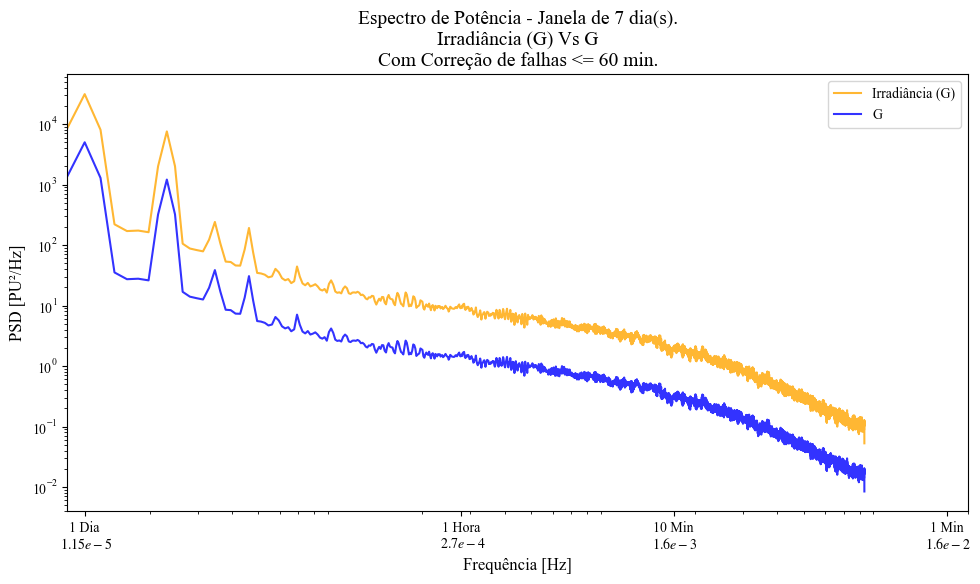

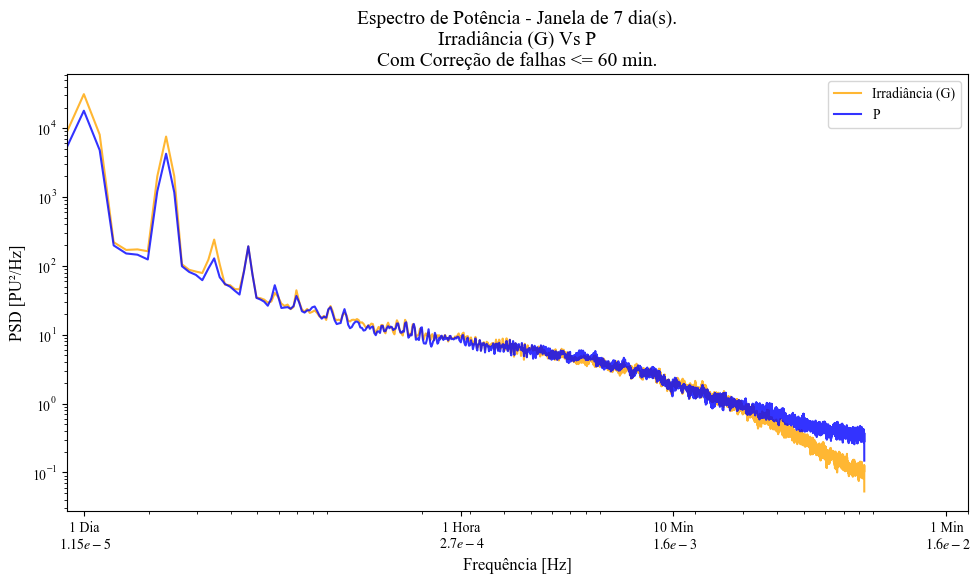

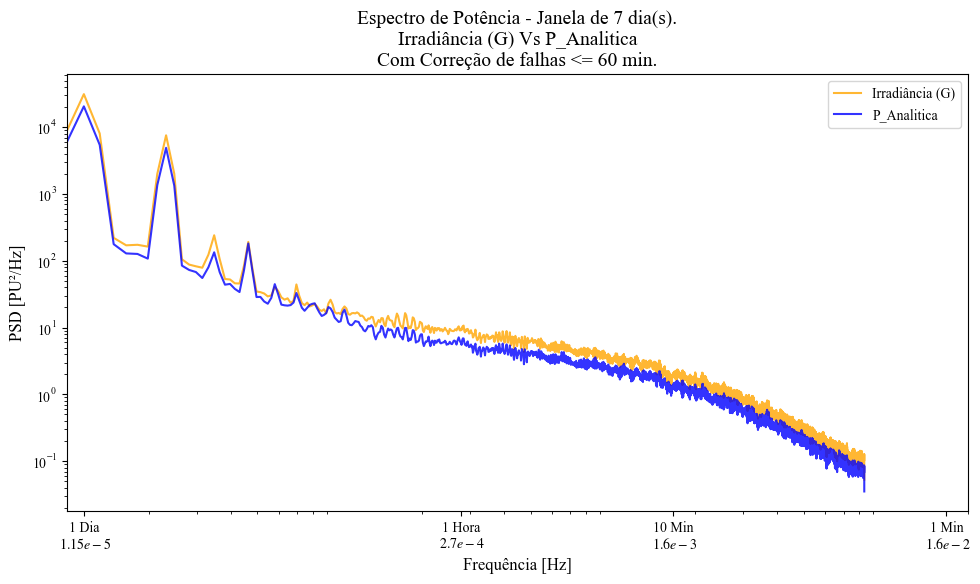

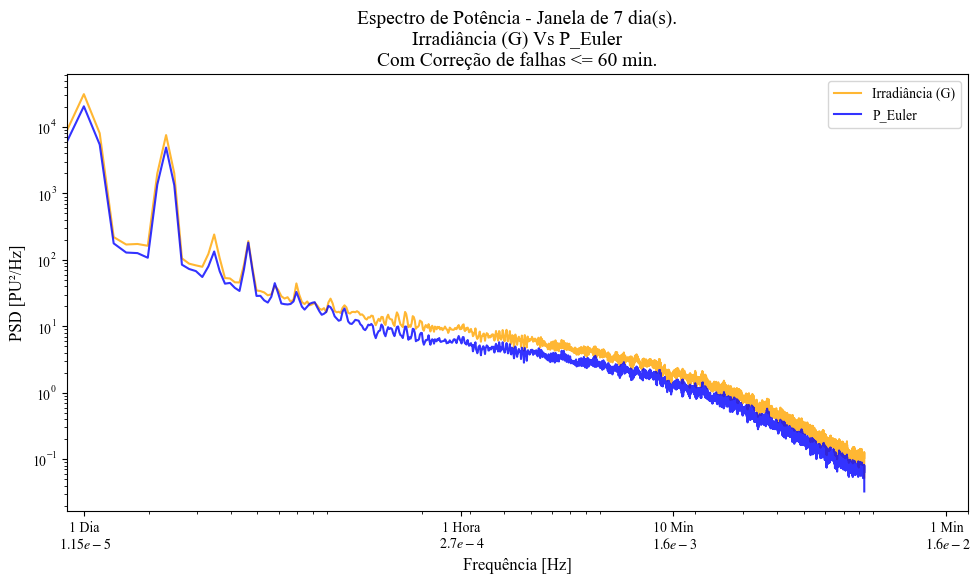

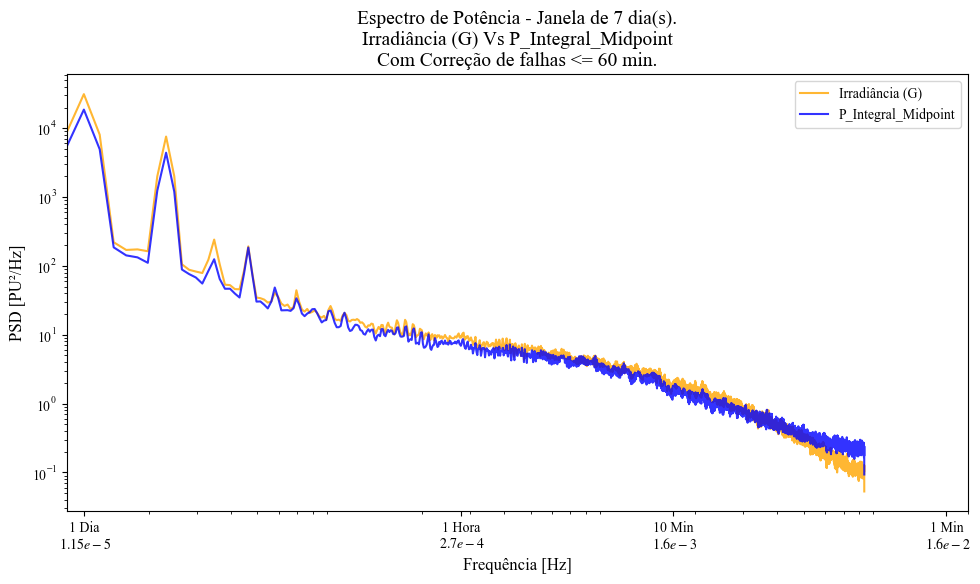

In [6]:
lista=['G','P', 'P_Analitica', 'P_Euler', 'P_Integral_Midpoint']
df = pd.DataFrame()
welch = MetodoDeWelch()
for item in lista:
    welch.AplicaMetodoDeWelch(df=st.loc['2019'], win_size=7*1440,coluna_potencia=f'{item}', NOME_COLUNA_PARA_PLOT=f'{item}', minuto_correção='60')
    if item[0]=='P':
        df[f'Espectro_{item}']=pd.Series(welch.ampli_P)    
    elif item[0]=='G':
        df[f'Espectro_{item}']=pd.Series(welch.ampli_G)    
    else:
        df['Frequencia_Eixo_X_Hz']=pd.Series(welch.frec)

## Incoerências Observadas (Problemas de Dados)

**O gráfico apresentou desvios críticos do esperado, rastreados até problemas de amostragem e qualidade dos dados:**

1) **Inversão do Efeito de Suavização (Alta Frequência):**

 * Ocorrência: A curva da Potência (P, azul) ficou acima da Irradiância (G, laranja) nas altas frequências.

 * Significado Incoerente: Isso sugere que a planta está, erroneamente, amplificando as flutuações rápidas (em vez de filtrá-las).

 * Causa Provável: A presença de dados zerados na potência ($P=0$) durante o dia com irradiância não nula ($G>0$). Tais eventos (como desligamento ou limitação) criam descontinuidades abruptas na série temporal. No domínio da frequência, essas descontinuidades se manifestam como ruído de alta frequência com alta energia, mascarando o efeito de suavização e elevando artificialmente o PSD de Potência.

2) **Ausência de Picos de Frequência Diária (Baixa Frequência)**

 * Ocorrência: Os picos nítidos de 24 horas (e 12 horas) em $f \approx 1.15 \times 10^{-5}$ Hz não são evidentes.

 * Causa Provável: O sensor foi desligado à noite (dados de 5:30h às 18h). O Método de Welch exige um sinal contínuo e a interrupção/truncamento noturno distorce a periodicidade de 24 horas, "espalhando" a energia do pico fundamental.

# Diante das incoerências, inicia-se a análise dos dados em busca de falhas na medição

# Verificando se há 525.600 Amostras _(Qtd. de Minutos em Um Ano)_

In [ ]:
texto1 = 'Amostras Em Um Ano: ..................'
tamnaho_do_df = len(st.index)
print(f'{texto1} {tamnaho_do_df}')

texto2 = 'Qtd. de Minutos em Um Ano: ...........'
minutos_em_um_ano = 365 * 24 * 60
print(f'{texto2}', minutos_em_um_ano)

texto3 = 'Percentual de Minutos Não coletadas: .'
percentual = ((minutos_em_um_ano - len(st.index))/minutos_em_um_ano)*100
print(f'{texto3} {percentual:.2f} {'%'}')

texto4 = 'Qtd. de Dados Não Coletados:..........'
print(f'{texto4}', minutos_em_um_ano - len(st.index))

# Identificando e Quantificando os "Buracos" nos Dados do Sensor

In [ ]:
# Calcula a diferença de tempo entre uma linha e a anterior
time_diffs = st.index.to_series().diff()
# Filtra onde a diferença é maior que 1 minuto
gaps = time_diffs[time_diffs > pd.Timedelta('1min')]
print(f"Total de 'gaps' na amostragem: ... {len(gaps)}")
gaps.head()

# Verificando se há _NaN_

* A tecnica `df.isna().sum()` retornou **False** para todos,
isso implica que há saltos temporais no registro da base.
Alguém poderia achar que o sensor fez o registro do tempo na coluna **Time**,
mas o valor da coluna da irradiancia e da potencia ficou com _NaN_
O teste mostra que não é o caso.

In [ ]:
print(st.isna().sum())

# SubPlot Com Gráfico de dispersão Para verificar como os registros de Potência e Irradiância ocorrem ao longo de _24h_

A análise do gráfico confirma tudo que já vinhamos notando:

* Dados NÃO **EXISTENTES** para periodos Noturnos (Antes das 5h e depois das 18h);
* Ideitifica-se valores **ZERADOS** para potência em horário de sol pleno. 

In [ ]:
config_visual = {
                'font.family': 'serif',
                'font.serif': ['Times New Roman'],
                'font.size': 12,
                'axes.labelsize': 12,
                'axes.titlesize': 14,
                'xtick.labelsize': 10,
                'ytick.labelsize': 10,
                'legend.fontsize': 10,
                'mathtext.fontset': 'stix'}

with plt.rc_context(config_visual):
    horas_decimais = df.index.hour + df.index.minute / 60
    plt.figure()
    plt.subplot(2, 1, 1)
    plt.scatter(horas_decimais, df['G'], s=0.5, alpha=0.1, color='orange')
    plt.title('[DADO ORIGINAL] Dispersão de Irradiância por Hora do Dia')
    plt.ylabel('Irradiância (W/m²)')
    plt.xlim(0, 24)
    plt.ylim(-50, 1492.9)
    plt.xticks(list(range(0, 25)))
    
    plt.subplot(2, 1, 2)
    plt.scatter(horas_decimais, df['P'], s=0.5, alpha=0.1, color='blue')
    plt.title('Dispersão de Potência por Hora do Dia')
    plt.xlabel('Horas Em Um Dia')
    plt.ylabel('Potência (kW)')
    plt.xlim(0, 24)
    plt.ylim(-300, 2700) 
    #plt.grid(True, alpha=0.1)
    plt.xticks(list(range(0, 25)))
    plt.tight_layout()
    save_path = './GRAFICOS/DADO_ORIGINAL_dispersão_da_irradiância_e_potencia_por_hora_do_dia.png'
    plt.savefig(save_path, format='png', dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

# Uma Análise Mais Profunda dos _`Gaps`_ Focada nos Dados Faltantes e Inconsistentes **No Período Diurno**

* Dados, mesmo que ausentes, se no período noturno, **são zeros por definição**.
A maior preocupação são os dados inconsistentes e ausentes nos períodos de sol, pois a inserção de dados que não sigam uma distribuição de probabilidade coerente com o fenômeno físico, necessariamente, adicionará viés aos valores de irradiação e potência, o que pode subestimar ou sobrestimar as flutuações, incorrendo em uma análise espectral errada no futuro.

# Determinando a Duração dos Dias Para o Ano Observado (2019)

In [ ]:
PreencherNoites = FeatureEngineering()
st = PreencherNoites.preencher_noites_fisica(st_entrada=st, lat=-9.398611, lon=-40.50, angulo=88, angulo_painel = 15, fuso_horario='America/Recife')
ReconstrutorSolar = ReconstrutorUsinaSolar(area_hectares=1.48, limite_minutos=60, janela_vizinhos=5, col_p='P', col_g='G')
st = ReconstrutorSolar.reconstruir_via_analitico(st)
st = ReconstrutorSolar.reconstruir_via_euler(st)
st = ReconstrutorSolar.reconstruir_via_integral_midpoint(st)

welch.AplicaMetodoDeWelch(df=st, coluna_potencia='P_Euler', NOME_COLUNA_PARA_PLOT='P_Euler', minuto_correção='60')
welch.AplicaMetodoDeWelch(df=st, coluna_potencia='P_Analitica', NOME_COLUNA_PARA_PLOT='P_Analitica', minuto_correção='60')
welch.AplicaMetodoDeWelch(df=st, coluna_potencia='P_Integral_Midpoint', NOME_COLUNA_PARA_PLOT='P_Integral_Midpoint', minuto_correção='60')

In [ ]:
BuracosDiurnos = Analisador_De_Buracos_Diurno()
BuracosDiurnos.plotar_relatorio(df=st)

In [ ]:
AnalisadorDePotenciaZeroComSolPresente = Analisador_De_Potencia_Zero_Com_Sol_Presente(col_p='P', col_g='G', limite_g=0)
AnalisadorDePotenciaZeroComSolPresente.plotar_relatorio(df=st)

# Considerando a Usina Como Um Filtro _Low-Pass_ Para correção de Falhas curtas e cutissimas `Igual ou Inferior a 5 Min.` 

Marcos et al. mostra que:


$$ \large H(s) = \frac{P(s)}{G(s)} = \frac{K}{\tau s + 1}$$

Onde:

* $P(s)$ é a saída (Potência).

* $G(s)$ é a entrada (Irradiação).

* $\tau$ é a constante de tempo baseada na área da usina em hectares ($\large \frac{\sqrt{S}}{2\pi \cdot 0.021}$).

## Manipulando $H(s)$ para aplicar a inversa de Laplace:

$$\large P(s) \cdot (\tau s + 1) = K \cdot G(s)$$

$$\large P(s) \cdot \tau s + P(s) = K \cdot G(s)$$

Aplicando ($\mathcal{L}^{-1}$), fica: 

$$\large h(t) = \mathcal{L}^{-1} \{H(s)\}$$

Então:

$$\large \tau \frac{dP(t)}{dt} + P(t) = K \cdot G(t)$$

Discretizando a derivada temporal via método de Euler (Retanglar Para frente - Backfoward):

$$\large \frac{dP(t)}{dt} \approx \frac{P[t] - P[t-1]}{\Delta t}$$

Onde:

* $\Delta t$ é o seu tempo de amostragem

Substituindo fica:

$$\large \tau \left( \frac{P[t] - P[t-1]}{\Delta t} \right) + P[t] = K \cdot G[t]$$

Isolando $\large P[t]$

$$\large \tau (P[t] - P[t-1]) + P[t] \Delta t = K G[t] \Delta t$$


$$\large P[t](\tau + \Delta t) = K G[t] \Delta t + \tau P[t-1]$$


$$\large P[t] = \left( \frac{\Delta t}{\tau + \Delta t} \right) K G[t] + \left( \frac{\tau}{\tau + \Delta t} \right) P[t-1]$$

Para simplificar a expressão, podems assumir que:

$$\large \alpha = \frac{\Delta t}{\tau + \Delta t}$$

$$\large 1 - \alpha = 1 - \left( \frac{\Delta t}{\tau + \Delta t} \right)$$

$$\large 1 - \alpha = \frac{\tau + \Delta t - \Delta t}{\tau + \Delta t}$$

$$\large 1 - \alpha = \frac{\tau}{\tau + \Delta t}$$

Então, substituindo na equação fica:

$$\large P[t] = \alpha \cdot (K \cdot G[t]) + (1 - \alpha) \cdot P[t-1]$$


## Anáise:

$$P[t] = \underbrace{\alpha}_{\text{Peso do Novo}} \cdot (\text{Entrada Atual}) + \underbrace{(1 - \alpha)}_{\text{Peso do Velho}} \cdot (\text{Histórico})$$

* $\large \alpha$: representa a contribuição do dado novo para a saída. 

* $(\large 1 - \alpha)$: Representa a contribuição da inércia (do estado anterior do sistema). Como a soma dos pesos é sempre $1$ ($\alpha + (1-\alpha) = 1$), isso garante que o filtro nunca vai criar ou destruir energia artificialmente, apenas balancear.

## Calculando $\alpha$:

* Área da Usina $(\large S)$: $\large 1,48$ hectares (calculado a partir dos 7.600 módulos).
* Tempo de Amostragem ($\large \Delta t$ ou $T_s$): $60$ segundos.

**1. Cálculo da Frequência de Corte ($\large f_c$)**

A equação empírica nos dá $\large f_c$ em Hz:

$$\large f_c = 0.021 \cdot S^{-0.5}$$

$$\large f_c = \frac{0,021}{\sqrt{S}}$$$$f_c = \frac{0,021}{\sqrt{1,48}}$$$$f_c \approx \frac{0,021}{1,21655}$$$$f_c \approx 0,01726 \, \text{Hz}$$

2. Determianando a Constante de Tempo $\large \tau$

$$\large \tau \triangleq \frac{1}{2\pi f_c}$$

A constante de tempo tau ($\tau$) é o inverso da frequência angular ($2\pi f_c$):

$$\tau = \frac{1}{2 \cdot 3,14 \cdot 0,01726}$$

$$\tau = \frac{1}{0,1084}$$$$\tau \approx 9,225 \, \text{segundos}$$

Isso significa que a usina leva cerca de 9,2 segundos para "sentir" plenamente o efeito de uma variação brusca de irradiância devido à sua inércia espacial.

Portanto $\alpha$ fica:

$$\large\alpha = \frac{\Delta t}{\tau + \Delta t}$$$$\large\alpha = \frac{60}{9,225 + 60}$$$$\large\alpha = \frac{60}{69,225}$$$$\large\mathbf{\alpha \approx 0,8667}$$

Isso significa que, a cada minuto, o valor da potência é composto por:

* 86,6% da irradiação que está chegando agora ($\alpha$).

* 13,4% da potência que já estava lá no minuto anterior ($1 - \alpha$).

Isso faz sentido físico: como a amostragem é lenta (1 min) e a usina é rápida (~9s), o "novo dado" tem muito mais peso que a "memória" do sistema.

In [ ]:
Instancia_Reconstrutor = ReconstrutorUsinaSolar(area_hectares=1.48, limite_minutos=5, janela_vizinhos=10, col_p='P', col_g='G')

# Aplica Euler (gera 'Euler_corrigida')
df_resultado = Instancia_Reconstrutor.reconstruir_via_euler(df_new_full_index)

# Aplica Analítico no dataframe retornado acima (gera 'Analitica_corrigida')
df_final = Instancia_Reconstrutor.reconstruir_via_analitico(df_resultado)


In [ ]:
AnalisadorDePotenciaZeroComSolPresente = Analisador_De_Potencia_Zero_Com_Sol_Presente(col_p='Euler_corrigida', col_g='G', limite_g=0)
AnalisadorDePotenciaZeroComSolPresente.plotar_relatorio(df_final)

In [ ]:
AnalisadorDePotenciaZeroComSolPresente = Analisador_De_Potencia_Zero_Com_Sol_Presente(col_p='Analitica_corrigida', col_g='G', limite_g=0)
AnalisadorDePotenciaZeroComSolPresente.plotar_relatorio(df_final)

In [ ]:
df_final

In [ ]:

dia = '2019-04-01'
inicio_zoom = '2019-03-01 08:00:00'
fim_zoom =    '2019-03-01 17:30:00'

df_zoom = df_final.loc[inicio_zoom:fim_zoom]

plt.figure(figsize=(12, 6))

# Agora usamos df_zoom para TUDO (index e colunas), garantindo alinhamento perfeito
plt.plot(df_zoom.index, df_zoom['P'], label='Potência Original (P)', linewidth=2, color = 'blue', alpha = 0.5)
plt.plot(df_zoom.index, df_zoom['Euler_corrigida'], label='Correção Euler', linestyle='--', color='orange')
plt.plot(df_zoom.index, df_zoom['Analitica_corrigida'], label='Correção Analítica', linestyle='-.', color='green')

plt.title(f'Detalhe da Correção: {dia} ({inicio_zoom.split(" ")[1]} - {fim_zoom.split(" ")[1]})')
plt.xlabel('Tempo')
plt.ylabel('Potência (kW)')
plt.legend(bbox_to_anchor=(1.0, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
config_visual = {
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'mathtext.fontset': 'stix'}

with plt.rc_context(config_visual):
    hours = df_final.index.hour
    mask_night = (hours < 7) | (hours >= 17)
    mask_day = ~mask_night
    df_day = df_final.loc[mask_day].copy()
    df_day = df_day.dropna()
    
    g_pu = (df_day['G'] / 1000).to_numpy()
    p_pu = (df_day['Analitica_corrigida'] / 2500).to_numpy()

    # Método de Welch
    fs = 1/60
    win_size = 4320 # Tamanho da janela
    noverlap = int(win_size / 2) 
    nfft = win_size 
    win = signal.windows.hann(win_size)

    f_g, Sgg = signal.csd(g_pu, g_pu, fs, window=win, noverlap=noverlap, nfft=nfft, scaling='density')
    f_p, Spp = signal.csd(p_pu, p_pu, fs, window=win, noverlap=noverlap, nfft=nfft, scaling='density')

    # --- Plotagem ---
    plt.figure()
    plt.loglog(f_g, Sgg, label='Irradiância (G)', alpha=0.8, color='orange')
    plt.loglog(f_p, Spp, label=r'Potência (P) [Falhas $\leq 5$ min.] Corrigidas', alpha=0.8, color='blue')
    plt.xlabel('Frequência [Hz]')
    plt.ylabel('PSD [PU²/Hz]')
    plt.title(
        'Espectro de Potência - Janela de 4320 min.\n' + 
        r'Com Falhas de Potência $\leq 5$ min. Corrigidas' + '\n' +
        #'Correção Feita Com Uso da Função De Tranferência Discretizada pelo Método do Euler\n' +
        r'Correção Feita Com Uso da Resolução da EDO e Aproximação da Integral Pelo Método do Valor Médio'+
        #r'$ P[t] = \alpha \cdot (K \cdot G[t]) + (1 - \alpha) \cdot P[t-1]$' + '\n' +
        '\n (Espectro Feito Com Uso do método de Welch)')
    
    plt.xlim(1e-5, 1e-2)
    plt.legend()
    plt.tight_layout()
    #plt.savefig('./GRAFICOS/Espectro_de_Potência_Correção_Feita_Com_Uso_da_Função_De_Tranferência_Discretizada_pelo_Método_de_Euler.png', format='png', dpi=600, bbox_inches='tight')
    plt.savefig('./GRAFICOS/Correção Feita Com Uso da Resolução da EDO e Aproximação da Integral Pelo Método do Valor Médio.png', format='png', dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

# Plot do Gráfico de Flutuação de Irradiancia

In [ ]:
# CÁLCULO DAS FLUTUAÇÕES DE IRRADIANCIA
deltas = [1, 10] # Delta t = 1 min e Delta t = 10 min
cores = ['red', 'cyan'] # Cores iguais ao artigo para 60s e 600s
irradiacao_de_referencia = 1000
for delta_t, cor in zip(deltas, cores):
    # O método .diff do Pandas: .diff(periods=k) faz G(t) - G(t-k)
    # A fórmula do artigo: (Diferença / 1000) * 100
    fluctuation_G = (df_new['G'].diff(periods=delta_t) / irradiacao_de_referencia) * 100
    # Remover o NaN gerados pelo .diff
    fluctuation_G = fluctuation_G.dropna()
    # CRIAÇÃO DO HISTOGRAMA (Bins de 1%)
    # faixas de -120% a +120% com passo de 1%
    bins = np.arange(-120, 121, 1) 
    # np.histogram conta quantos eventos caem em cada faixa
    counts, bin_edges = np.histogram(fluctuation_G, bins=bins)
    # Calcular o centro de cada bin para plotar a linha
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    # NORMALIZAÇÃO (O Eixo Y)
    # Frequência Relativa (%) = (Contagem / Total) * 100
    rel_freq = (counts / len(fluctuation_G)) * 100
    # PLOTAGEM (Escala Log-Linear)
    # Filtra valores com frequencia 0 para não quebrar o log
    mask = rel_freq > 0
    plt.plot(bin_centers[mask], rel_freq[mask], 
             label=f'Δt = {delta_t} min', 
             color=cor, linewidth=1.5)
plt.yscale('log')
plt.xlabel('Flutuação de irradiância (%)', fontsize=13)
plt.ylabel('Frequência Relativa(%)', fontsize=13)
plt.title('[DADO TRATADO] Distribuição das Flutuações de Irradiância (Escala Log-Linear) \n Planta Solar de Petrolina - 2,5MW', fontsize=14)
#plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.ylim(10**-4, 100) # Ajuste similar ao artigo
plt.xlim(-120, 120)
plt.xticks([-120, -100, -80, -60, -40, -20, 0, 20, 40, 60, 80, 100, 120])
plt.tight_layout()
plt.savefig('./GRAFICOS/DADO_TRATADO_distribuicao_da_irradiancia.png', format='png', dpi=600, bbox_inches='tight')

# Plot do Gráfico de Futuação de Potencia

In [ ]:
# CÁLCULO DAS FLUTUAÇÕES POTENCIA
deltas = [1, 10] # Delta t = 1 min e Delta t = 10 min
cores = ['red', 'cyan'] # Cores iguais ao artigo para 60s e 600s
potecia_de_referencia = 2500
for delta_t, cor in zip(deltas, cores):
    # O método .diff do Pandas: .diff(periods=k) faz G(t) - G(t-k)
    # A fórmula do artigo: (Diferença / 1000) * 100
    fluctuation_P = (df_new['P'].diff(periods=delta_t) / potecia_de_referencia) * 100
    # Remover o NaN gerados pelo .diff
    fluctuation_P = fluctuation_P.dropna()
    # 2. CRIAÇÃO DO HISTOGRAMA (Bins de 1%)    
    # faixas de -120% a +120% com passo de 1%
    bins = np.arange(-120, 121, 1) 
    # np.histogram conta quantos eventos caem em cada faixa
    counts, bin_edges = np.histogram(fluctuation_P, bins=bins)
    # Calcular o centro de cada bin para plotar a linha
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    # NORMALIZAÇÃO (O Eixo Y)
    # Frequência Relativa (%) = (Contagem / Total) * 100
    rel_freq = (counts / len(fluctuation_P)) * 100
    # PLOTAGEM (Escala Log-Linear)
    # Filtra valores com frequencia 0 para não quebrar o log
    mask = rel_freq > 0
    plt.plot(bin_centers[mask], rel_freq[mask], 
             label=f'Δt = {delta_t} min', 
             color=cor, linewidth=1.5)
plt.yscale('log')
plt.xlabel('Flutuação de Potência (%)', fontsize=13)
plt.ylabel('Frequência Relativa(%)', fontsize=13)
plt.title('[DADO TRATADO] Distribuição das Flutuações de Potência (Escala Log-Linear) \n Planta Solar de Petrolina - 2,5MW', fontsize=14)
#plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.ylim(10**-4, 100) # Ajuste similar ao artigo
plt.xlim(-120, 120)
plt.xticks([-120, -100, -80, -60, -40, -20, 0, 20, 40, 60, 80, 100, 120])
plt.tight_layout()
plt.savefig('./GRAFICOS/DADO_TRATADO_distribuicao_da_potencia.png', format='png', dpi=600, bbox_inches='tight')